In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
from sklearn.model_selection import learning_curve as sk_learning_curve

import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
import plotly.express as px

In [17]:
# nltk.download('averaged_perceptron_tagger')
# nltk.download('averaged_perceptron_tagger_eng') # New version for some NLTK releases

# # Required for Tokenization and Lemmatization
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('omw-1.4')

Dataset Check

In [34]:
data = pd.read_json('train_data.jsonl', lines=True)
print(data.head())

                                            raw_text    dialect  \
0  Lagee nyang ka tateupeue, kue brownies nyang a...       Aceh   
1  Gorontalo (ANTARA News) - Menteri Pertanian RI...  Indonesia   
2  Jakarta, CNN Indonesia - - Melamar kekasih unt...  Indonesia   
3  Selamat pagi. Wah kecewa berat masa indihome i...  Indonesia   
4  Perayaan Natal Pemprov DKI Jakarta yang digela...  Indonesia   

                                             summary  urgency_score  \
0  Teks berbahasa Aceh mengungkapkan pandangan ne...           0.70   
1  Menteri Pertanian RI Andi Amran Sulaiman melep...           0.62   
2  Vinny Capaldo - Smith (30 tahun) adalah seoran...           0.38   
3  Teks berbahasa Indonesia mengungkapkan pandang...           0.73   
4  Perayaan Natal Pemprov DKI Jakarta yang digela...           0.45   

               target_agency  \
0  Dinas terkait / Ombudsman   
1               Dinas Sosial   
2      Kelurahan / Kecamatan   
3  Dinas terkait / Ombudsman   
4      Kel

In [35]:
print(data.shape)

(9276, 6)


In [36]:
print(data.columns)

Index(['raw_text', 'dialect', 'summary', 'urgency_score', 'target_agency',
       'reasoning'],
      dtype='str')


In [37]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 9276 entries, 0 to 9275
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   raw_text       9276 non-null   str    
 1   dialect        9276 non-null   str    
 2   summary        9276 non-null   str    
 3   urgency_score  9276 non-null   float64
 4   target_agency  9276 non-null   str    
 5   reasoning      9276 non-null   str    
dtypes: float64(1), str(5)
memory usage: 6.6 MB
None


In [38]:
#Dropping unused columns

cols_to_drop = ['target_agency','summary', 'urgency_score', 'reasoning']

data = data.drop(columns=cols_to_drop)

data.head()

,raw_text,dialect
0,"Lagee nyang ka tateupeue, kue brownies nyang a...",Aceh
1,Gorontalo (ANTARA News) - Menteri Pertanian RI...,Indonesia
2,"Jakarta, CNN Indonesia - - Melamar kekasih unt...",Indonesia
3,Selamat pagi. Wah kecewa berat masa indihome i...,Indonesia
4,Perayaan Natal Pemprov DKI Jakarta yang digela...,Indonesia


In [39]:
x = data['raw_text']
y = data['dialect']

# Split the data (80% training, 20% testing)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

EDA

In [40]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9276 entries, 0 to 9275
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   raw_text  9276 non-null   str  
 1   dialect   9276 non-null   str  
dtypes: str(2)
memory usage: 4.1 MB


In [25]:
data.describe(include=object)

C:\Users\rmksu\AppData\Local\Temp\ipykernel_34420\3757873171.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=object)


,raw_text,dialect,target_agency
count,9275,9275,9275
unique,9275,12,17
top,"Lagee nyang ka tateupeue, kue brownies nyang a...",Indonesia,Kelurahan / Kecamatan
freq,1,3168,4077


In [41]:
missing_summary = pd.DataFrame({
    'Missing_Count': data.isnull().sum(),
    'Missing_Percentage' : (data.isnull().sum().mean() *100).round(2)
})

missing_summary

,Missing_Count,Missing_Percentage
raw_text,0,0.0
dialect,0,0.0


Distribution of dialect:
dialect
Indonesia    3168
Jawa          649
Minang        645
Banjar        645
Batak         645
Bali          644
Aceh          643
Bugis         643
Madura        641
Sunda         640
Melayu        158
Betawi        155
Name: count, dtype: int64

Percentage Distribution:
dialect
Indonesia    34.15
Jawa          7.00
Minang        6.95
Banjar        6.95
Batak         6.95
Bali          6.94
Aceh          6.93
Bugis         6.93
Madura        6.91
Sunda         6.90
Melayu        1.70
Betawi        1.67
Name: count, dtype: float64


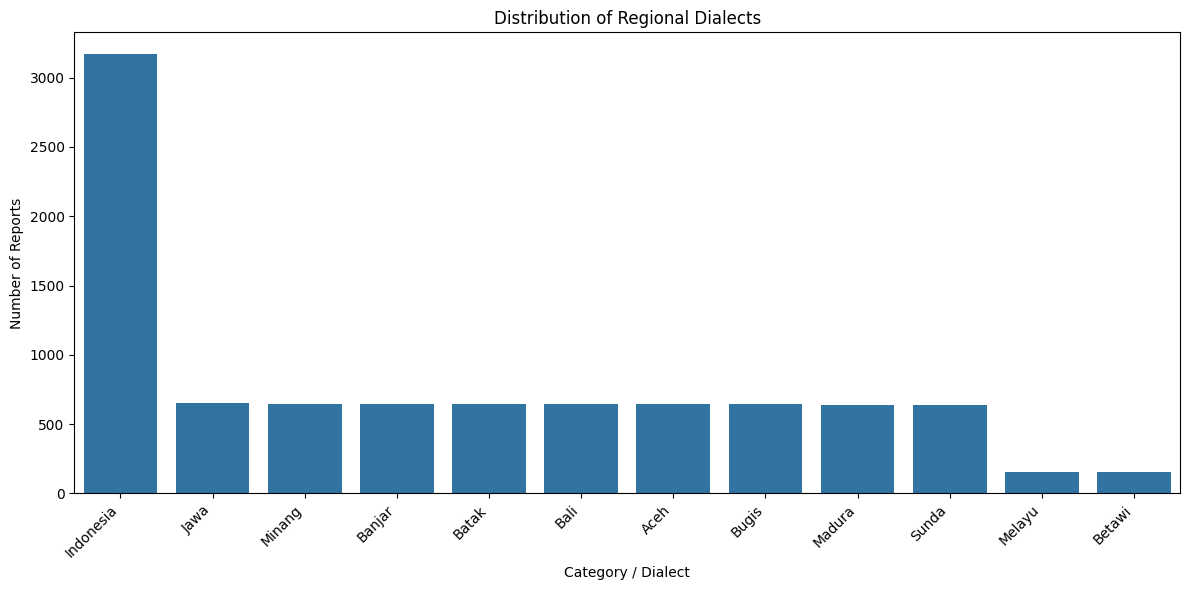

In [42]:
genre_counts = data['dialect'].value_counts()

print("Distribution of dialect:")
print(genre_counts)

# Percentage distribution
genre_percent = (genre_counts / len(data) * 100).round(2)

print("\nPercentage Distribution:")
print(genre_percent)

# Visualization
plt.figure(figsize=(12,6))
sns.barplot(
    x=genre_counts.index,
    y=genre_counts.values
)

plt.title("Distribution of Regional Dialects")
plt.xlabel("Category / Dialect")
plt.ylabel("Number of Reports")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Preprocessing

In [ ]:
#Preprocessing


def lemmatizing(word_list):
    return word_list

def preprocessing(sentence):
    punctuations = set(string.punctuation)

    sentence = str(sentence).lower()

    word_list = word_tokenize(sentence)

    filtered = [
        token for token in word_list
        if token not in punctuations
        and token.isalpha()
    ]

    return lemmatizing(filtered)


In [44]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold


In [45]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tfidf_params = dict(
    tokenizer=preprocessing,
    token_pattern=None,   
    ngram_range=(1, 2),   
    max_features=15000,   
    sublinear_tf=True,    
    min_df=2,             
    max_df=0.85,
)

In [46]:
models = {
    # Using Linear SVC only as the champion model configuration
    "Linear SVC": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",   LinearSVC(
            C=0.1,
            max_iter=5000,
            class_weight="balanced",
            random_state=42  # Added to ensure reproducible results across notebook runs
        ))
    ]),
}

In [47]:
results_summary = {}

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")

    print("Training model...")
    model.fit(x_train, y_train)

    # Test performance
    y_pred = model.predict(x_test)
    print("\n[Test Set Report]")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Train F1 — if much higher than CV, the model is overfitting
    train_f1 = f1_score(y_train, model.predict(x_train), average="macro", zero_division=0)

    # CV with StratifiedKFold — honest generalisation estimate
    print("Calculating 5-Fold Cross Validation (this may take a moment)...")
    cv_scores = cross_val_score(model, x_train, y_train, cv=skf, scoring="f1_macro")
    cv_mean   = cv_scores.mean()
    test_f1   = f1_score(y_test, y_pred, average="macro", zero_division=0)
    gap       = train_f1 - cv_mean

    print(f"\n  Train F1 (macro):       {train_f1:.4f}")
    print(f"  CV F1   (macro):        {cv_mean:.4f}  (+/- {cv_scores.std():.4f})")
    print(f"  Test F1 (macro):        {test_f1:.4f}")
    flag = "<-- Good (gap < 0.05)" if gap < 0.05 else "<-- Overfitting"
    print(f"  Overfit Gap (Train-CV): {gap:.4f}  {flag}")

    results_summary[name] = {
        "Train F1": train_f1,
        "CV F1":    cv_mean,
        "Test F1":  test_f1,
        "Gap":      gap,
    }


  Linear SVC
Training model...

[Test Set Report]
              precision    recall  f1-score   support

        Aceh       0.99      0.93      0.96       129
        Bali       0.98      0.94      0.96       129
      Banjar       0.97      0.88      0.92       129
       Batak       0.99      0.98      0.98       129
      Betawi       0.60      1.00      0.75        31
       Bugis       1.00      0.95      0.98       129
   Indonesia       0.98      0.96      0.97       634
        Jawa       0.94      0.99      0.97       130
      Madura       0.93      1.00      0.97       128
      Melayu       0.57      0.90      0.70        31
      Minang       0.96      0.91      0.94       129
       Sunda       0.97      0.92      0.94       128

    accuracy                           0.95      1856
   macro avg       0.91      0.95      0.92      1856
weighted avg       0.96      0.95      0.95      1856

Calculating 5-Fold Cross Validation (this may take a moment)...

  Train F1 (macro

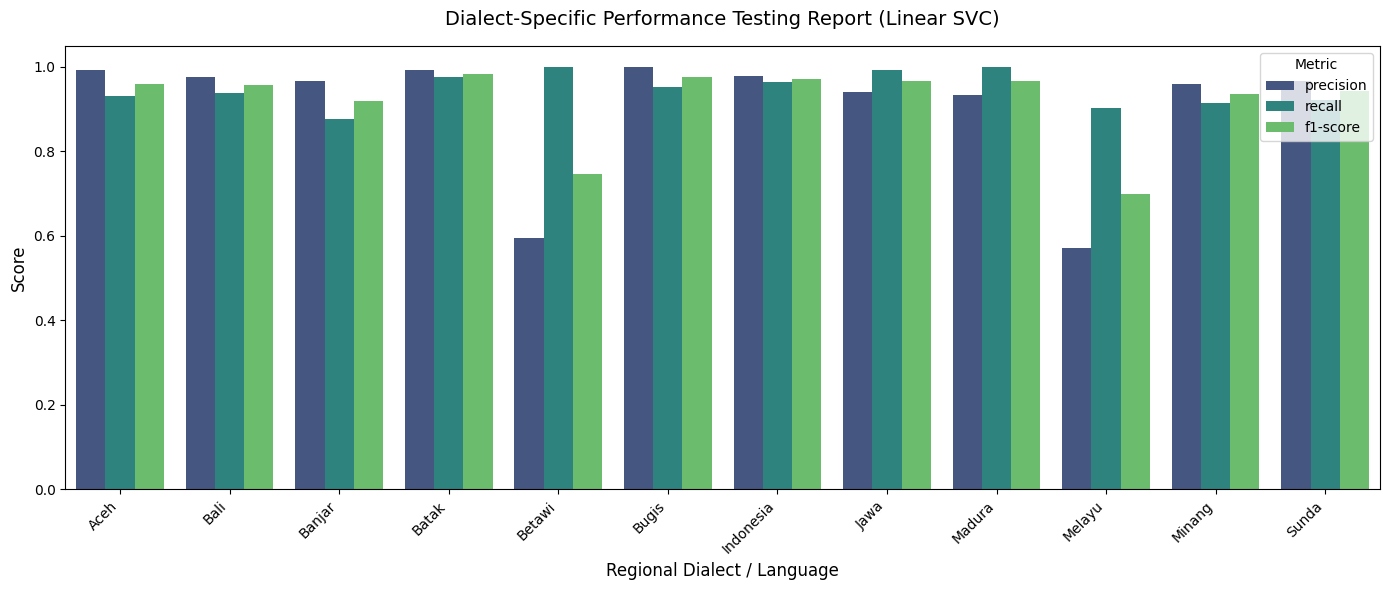

      Dialect  precision    recall  f1-score
3       Batak   0.992126  0.976744  0.984375
5       Bugis   1.000000  0.953488  0.976190
6   Indonesia   0.979167  0.963722  0.971383
7        Jawa   0.941606  0.992308  0.966292
8      Madura   0.934307  1.000000  0.966038
0        Aceh   0.991736  0.930233  0.960000
1        Bali   0.975806  0.937984  0.956522
11      Sunda   0.967213  0.921875  0.944000
10     Minang   0.959350  0.914729  0.936508
2      Banjar   0.965812  0.875969  0.918699
4      Betawi   0.596154  1.000000  0.746988
9      Melayu   0.571429  0.903226  0.700000


In [48]:
# Create a list to store metrics for each individual dialect class
dialect_metrics_list = []

for name, model in models.items():
    # Generate predictions using the champion model
    y_pred = model.predict(x_test)
    
    # 1. Get the full classification report as a dictionary
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # 2. Extract every individual dialect category instead of just 'macro avg'
    for key, metrics in report.items():
        # Exclude system summary rows so we only look at the dialect labels
        if key not in ['accuracy', 'macro avg', 'weighted avg']:
            # Capture class-specific values matching your original dictionary keys
            class_metrics = {
                'Dialect': key,
                'precision': metrics['precision'],
                'recall': metrics['recall'],
                'f1-score': metrics['f1-score'],
                'Model': name
            }
            dialect_metrics_list.append(class_metrics)

# 4. Create a DataFrame for easy visualization/analysis
df_dialect = pd.DataFrame(dialect_metrics_list)

# Melt the data frame to align Precision, Recall, and F1-Score side-by-side
df_melted = df_dialect.melt(id_vars='Dialect', value_vars=['precision', 'recall', 'f1-score'], 
                          var_name='Metric', value_name='Score')

# Optional: Visualize the averages across all regional dialects
plt.figure(figsize=(14, 6))
sns.barplot(data=df_melted, x='Dialect', y='Score', hue='Metric', palette='viridis')
plt.title('Dialect-Specific Performance Testing Report (Linear SVC)', fontsize=14, pad=15)
plt.ylim(0.0, 1.05)  # Set full scale to observe individual category variances clearly
plt.xlabel('Regional Dialect / Language', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display the summary table sorted by f1-score to immediately see your strongest/weakest dialects
print(df_dialect[['Dialect', 'precision', 'recall', 'f1-score']].sort_values(by='f1-score', ascending=False))

In [49]:
test_data = pd.read_json('test_data.jsonl', lines=True)
x_test_new = test_data['raw_text']
y_test_new = test_data['dialect']

# Then test any model
for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  {name} (Unseen Generalization Test)")
    print(f"{'='*55}")
    
    y_pred = model.predict(x_test_new)
    
    print(classification_report(y_test_new, y_pred, zero_division=0))


  Linear SVC (Unseen Generalization Test)
              precision    recall  f1-score   support

        Aceh       0.98      0.95      0.97       137
        Bali       0.99      0.97      0.98       138
      Banjar       0.97      0.92      0.94       138
       Batak       0.99      0.98      0.99       139
      Betawi       0.64      0.97      0.77        33
       Bugis       0.99      0.99      0.99       138
   Indonesia       0.98      0.96      0.97       678
        Jawa       0.96      0.96      0.96       139
      Madura       0.96      0.99      0.98       138
      Melayu       0.63      0.94      0.76        33
      Minang       0.98      0.94      0.96       139
       Sunda       0.97      0.94      0.96       138

    accuracy                           0.96      1988
   macro avg       0.92      0.96      0.94      1988
weighted avg       0.97      0.96      0.96      1988



C:\Users\rmksu\AppData\Local\Temp\ipykernel_34420\2311041403.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df2, x='Metric', y='Score', palette='magma')


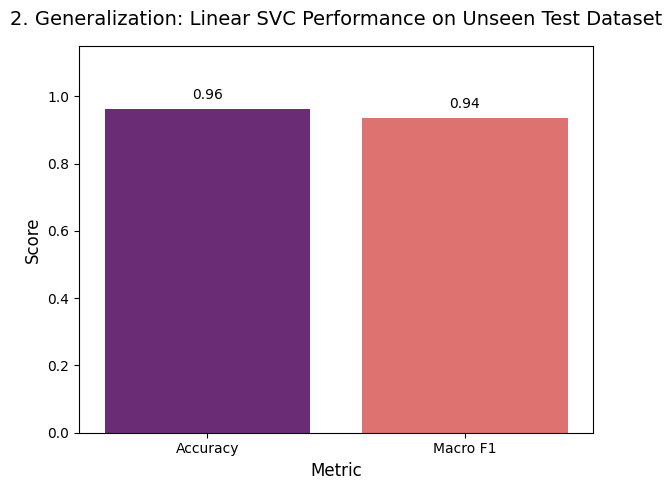

C:\Users\rmksu\AppData\Local\Temp\ipykernel_34420\2311041403.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df3, x='F1-Score', y='Category', palette='Blues_r')


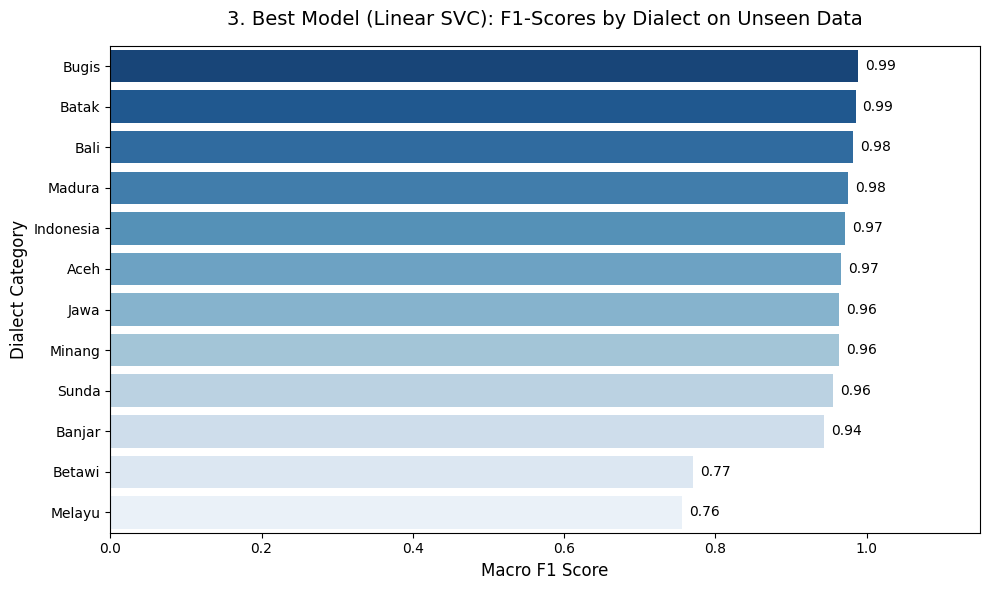

In [50]:
from sklearn.metrics import accuracy_score, f1_score

y_pred = models["Linear SVC"].predict(x_test_new)

# =====================================================================
# 2. Generalization: Performance on Unseen Test Dataset
# =====================================================================
# Dynamically compute the metrics instead of using hardcoded dummy placeholders
test_acc = accuracy_score(y_test_new, y_pred)
test_f1_macro = f1_score(y_test_new, y_pred, average="macro", zero_division=0)

df2 = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro F1'],
    'Score': [test_acc, test_f1_macro]
})

plt.figure(figsize=(6, 5))
sns.barplot(data=df2, x='Metric', y='Score', palette='magma')
plt.title('2. Generalization: Linear SVC Performance on Unseen Test Dataset', fontsize=14, pad=15)
plt.ylim(0.0, 1.15)  # Headroom adjusted for labels
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metric', fontsize=12)

# Improved annotation logic
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.2f}", 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='bottom', xytext=(0, 5), 
                       textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

# =====================================================================
# 3. Best Model (Linear SVC): F1-Scores by Category (Dialects)
# =====================================================================
# Extract the full classification report dictionary dynamically
report = classification_report(y_test_new, y_pred, output_dict=True, zero_division=0)

classes = []
svc_f1 = []

# Populate lists with individual dialect names and their corresponding scores
for key, metrics in report.items():
    if key not in ['accuracy', 'macro avg', 'weighted avg']:
        classes.append(key)
        svc_f1.append(metrics['f1-score'])

df3 = pd.DataFrame({'Category': classes, 'F1-Score': svc_f1})
df3 = df3.sort_values('F1-Score', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df3, x='F1-Score', y='Category', palette='Blues_r')
plt.title('3. Best Model (Linear SVC): F1-Scores by Dialect on Unseen Data', fontsize=14, pad=15)
plt.xlim(0.0, 1.15)  # Adjusted to avoid cutting off labels
plt.xlabel('Macro F1 Score', fontsize=12)
plt.ylabel('Dialect Category', fontsize=12)

# Improved annotation logic for horizontal bars
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_width():.2f}", 
                       (p.get_width(), p.get_y() + p.get_height() / 2.), 
                       ha='left', va='center', xytext=(5, 0), 
                       textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

In [52]:
def classify(text: str):
    """
    Classify input text to detect its underlying dialect.
    Usage: classify("your text here")
    """
    if not text.strip():
        print("Please enter some text to analyze.")
        return

    # Predict using the champion dialect model
    pred = models["Linear SVC"].predict([text])[0]

    print()
    print("=" * 60)
    print("  INPUT TEXT:")
    print(f"  {text}")
    print("-" * 60)
    print(f"  Detected Dialect / Language: {pred}")
    print("=" * 60)
    print()

# ── Try dialect detection tests ──────────────────────────────────────────
# Test 1: Aceh dialect text sample
classify("Lagee nyang ka tateupeue, kue brownies nyang asli dari Amerika nyankeuh kue banteut wareuna coklat.")

# Test 2: Standard Indonesian text sample
classify("Menteri Pertanian RI melepas ekspor jagung produksi Gorontalo ke Filipina hari ini.")

# Test 3: Betawi dialect text sample
classify("Jangan lupa entar malem kita kumpul di rumah aye ya, jagoan kagak boleh telat!")

classify("Ini jalanan kampung kagak dibener-benerin dari taon jemot. Banyak lobang gede bener, kalo ujan deres udah berasa kayak empang lele dah ah!")

# Public facility complaint
classify("Lampu penerangan jalanan di mari pada mati semuanya, kalo malem jadi serem bener, takut ada begal lewat.")

# Road condition complaint (wes rusak parah, bolong-bolong, koyo balong)
classify("Dalan neng ngarep omahku iki wes rusak parah, bolong-bolong kabeh. Nek udan dadi koyo balong, mbok yo ndang didandani toh pak.")

# Public service complaint (suwe banget, ngantri)
classify("Maksude piye toh iki? Ngurus surat ngene wae suwe banget ramutu, jarene jaman wis online tapi kok sek ngantri mbulet.")

# Polite/Standard Sundanese complaint (parantos ruksak pisan, seueur liang, bilih aya nu cilaka)
classify("Jalan di payuneun rorompok teh parantos ruksak pisan, seueur liang ageung. Upami tiasa mah mangga geura dilereskeun bapa, bilih aya nu cilaka.")

# Trash accumulation complaint
classify("Ieu tumpukan runtah di sisi jalan naha teu diangkut-angkut nya? Ambeuna tos bau pisan, ngaganggu kanu ngalangkung.")



  INPUT TEXT:
  Lagee nyang ka tateupeue, kue brownies nyang asli dari Amerika nyankeuh kue banteut wareuna coklat.
------------------------------------------------------------
  Detected Dialect / Language: Aceh


  INPUT TEXT:
  Menteri Pertanian RI melepas ekspor jagung produksi Gorontalo ke Filipina hari ini.
------------------------------------------------------------
  Detected Dialect / Language: Bugis


  INPUT TEXT:
  Jangan lupa entar malem kita kumpul di rumah aye ya, jagoan kagak boleh telat!
------------------------------------------------------------
  Detected Dialect / Language: Betawi


  INPUT TEXT:
  Ini jalanan kampung kagak dibener-benerin dari taon jemot. Banyak lobang gede bener, kalo ujan deres udah berasa kayak empang lele dah ah!
------------------------------------------------------------
  Detected Dialect / Language: Betawi


  INPUT TEXT:
  Lampu penerangan jalanan di mari pada mati semuanya, kalo malem jadi serem bener, takut ada begal lewat.
-----------